# Donation-Intent Classifier — v4 (augmentation fixed)

Two-head classification of Persuasion-For-Good dialogues:

* `binary_label` ∈ {`no`, `yes`} — did the Persuadee commit to donating?
* `modifier` ∈ {`none`, `deferred`, `conditional`} — what kind of commitment?

This notebook implements **Idea 4 (Data Augmentation Suite)** from the project
README, and repairs the defects that made the previous augmented run score
*below* the speaker-aware run.

---

## What was wrong in v3, and what changed here

| # | Defect in v3 | Impact | Fix in v4 |
|---|---|---|---|
| 1 | `truncation=True` with the HuggingFace default `truncation_side="right"` and `max_length=256`. **99.5 %** of these dialogues are longer than 256 tokens (median 523), and the Persuadee's decisive commitment sits at ~96 % of the way through *every* dialogue. **99.3 % of rows lost their final 60 characters.** | The model never saw the sentence that defines the label. It could only learn the class prior — which is precisely why every encoder landed on the majority baseline. | `truncation_side="left"` (keep the **end**) and `max_length=512`. |
| 2 | Modifier loss, class weights and the headline metric were all masked to `binary_label=="yes"` rows. | The data does **not** work that way: 65 of the 146 informative modifiers (44 %) sit on `no` rows — `no\|deferred`=57, `no\|conditional`=8 — exactly as the annotation guideline specifies. Masking discarded 44 % of the minority signal and evaluated `conditional` on ~2 test rows. | Modifier is trained and evaluated on **all** rows. Yes-conditioned score kept as a secondary diagnostic. |
| 3 | Augmentation copied **every** `binary="no"` row, shifting the training prior from 72/28 to ~50/50 while val/test stayed at 72/28. | Train/eval prior mismatch; the tuned threshold then fought to undo it. | Augment **only** the starved `deferred` / `conditional` strata. The binary prior is left essentially intact, and the before/after table is printed for audit. |
| 4 | EDA ran at `alpha=0.15` over the **whole** 400-word dialogue, including the Persuadee's turns. Random deletion could delete the very sentence that carries the label. | Silent label corruption — the augmented rows were partly mislabelled, which is why more augmentation made results *worse*. | **Only `[Persuader]` turns are ever modified.** Per the annotation guideline the label depends solely on what the *Persuadee* says, so this is provably label-preserving. `alpha` lowered to 0.05. |
| 5 | The synonym table held 21 words, so the "synonym" op was usually a no-op and emitted near-duplicate rows. | Duplicates inflate the minority count without adding information — the model just overfits them. | Larger table **and** a guarantee that each augmented row actually differs from its source, else it is discarded. |
| 6 | Seeds came from Python's `hash()`, which is randomised per process. | Runs were not reproducible. | Stable `hashlib`-based seeding. |
| 7 | Headline binary metric was the positive-class F1 (majority baseline = 0.841), which hides real movement. | Improvements were invisible. | **Macro**-F1 for model selection and reporting (majority baseline = 0.42). Positive-class F1 still shown. |

Section 2b reproduces the dataset study that justifies fixes 1–3 — run it and
read it before trusting any number below.

---

## How to run on Kaggle

1. **Add the data.** *Add Input → Datasets →* your dataset containing
   `Manual_Label.csv`. Section 2 searches `/kaggle/input` recursively and picks
   the first CSV that actually has the expected columns, so the folder layout
   does not matter.
2. **Settings.** *Accelerator =* **GPU T4** (single T4 is enough) ·
   *Internet =* **ON** (the three encoders are downloaded from the Hub).
3. **Run All.** Expect **≈20–30 min** for all three encoders.

Two knobs worth knowing, both in the `CONFIG` block:

| Knob | Default | Use |
|---|---|---|
| `FAST_DEV_RUN` | `False` | `True` → 1 encoder, 1 epoch, ~120 rows, ≈2 min. Wiring check. |
| `use_augmentation` | `True` | `False` isolates the truncation fix from Idea 4. |

If an encoder fails to download, the run **skips it and continues** with the
rest rather than aborting.



## 0. Environment


In [1]:
# Kaggle images already carry these; the install is a no-op there and a
# convenience when running elsewhere. Never fails the run.
import subprocess, sys

def _pip(*args):
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args],
                       check=False, timeout=900)
    except Exception as exc:
        print("pip skipped:", exc)

try:
    import transformers, sentencepiece  # noqa: F401
    print("transformers", transformers.__version__, "- deps already present")
except Exception:
    _pip("transformers>=4.30", "sentencepiece")
    import transformers  # noqa: F401
    print("installed transformers", transformers.__version__)


transformers 5.0.0 - deps already present


## 1. Imports & configuration


In [2]:
import os, re, json, glob, gc, time, math, random, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE} | torch {torch.__version__}")
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

CONFIG = {
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],
    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",

    "column_map": {"text": "dialogue_text",
                   "binary_label": "binary_label",
                   "modifier": "modifier"},

    "binary_classes":   ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base"},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base",
         "lr": 8e-6, "batch_size": 8, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1"},
    ],

    # ---- FIX 1: keep the END of the dialogue -------------------------------
    # The label-bearing Persuadee commitment is at the tail of every dialogue.
    "max_length": 512,
    "truncation_side": "left",

    "train_frac": 0.70, "val_frac": 0.15, "test_frac": 0.15,

    "batch_size": 8, "eval_batch_size": 16,
    "num_epochs": 12, "lr": 2e-5, "weight_decay": 0.01,
    "warmup_ratio": 0.10, "max_grad_norm": 1.0,
    "early_stopping_patience": 4,

    "binary_loss_weight": 1.0,
    "modifier_loss_weight": 0.7,
    "label_smoothing": 0.05,

    "use_class_weights": True,
    "use_speaker_roles": True,

    # ---- FIX 2: modifier is defined for BOTH yes and no rows ---------------
    "modifier_on_all_rows": True,

    # ---- FIX 3+4: augmentation (Idea 4) -----------------------------------
    "use_augmentation": True,
    "aug_alpha": 0.05,              # was 0.15 - far too strong for long text
    "aug_persuader_only": True,     # never touch Persuadee text
    # target size per starved stratum; `none` strata are never augmented
    "aug_targets": {"deferred": 150, "conditional": 90},
    "aug_max_copies": 8,

    # optional; default OFF so the notebook cannot fail on a model download
    "use_backtranslation": False,

    # wiring check: 1 encoder, 1 epoch, tiny subset (~2 min)
    "FAST_DEV_RUN": False,
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
print("output dir:", CONFIG["out_dir"])


device: cuda | torch 2.10.0+cu128
GPU: Tesla T4
output dir: /kaggle/working


## 2. Load the labelled dataset


In [3]:
def find_csv(roots, tokens=("label",)):
    hits = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _d, files in os.walk(root):
            for fn in files:
                low = fn.lower()
                if low.endswith(".csv") and all(t in low for t in tokens):
                    hits.append(os.path.join(dirpath, fn))
    return sorted(set(hits))

paths = find_csv(CONFIG["search_roots"], ("manual", "label")) or \
        find_csv(CONFIG["search_roots"], ("label",))
print("candidate CSVs:")
for p in paths:
    print("  -", p)
assert paths, ("No labelled CSV found. Add Manual_Label.csv as a Kaggle Dataset "
               "input, or drop it next to this notebook.")

# Prefer a file that actually carries the expected columns.
cm = CONFIG["column_map"]
csv_path = None
for p in paths:
    try:
        head = pd.read_csv(p, nrows=5)
    except Exception:
        continue
    if cm["binary_label"] in head.columns and cm["text"] in head.columns:
        csv_path = p
        break
assert csv_path, f"None of the CSVs found have columns {list(cm.values())}"
print("\nusing:", csv_path)

raw = pd.read_csv(csv_path, keep_default_na=False, dtype=str)
print("raw shape:", raw.shape)

# ---- normalisation ------------------------------------------------------
# The five annotators disagreed on casing/whitespace: 'Yes', 'No ', ''.
# Without this a naive groupby silently splits `yes` from `Yes`.
df = pd.DataFrame({
    "text":         raw[cm["text"]].astype(str),
    "binary_label": raw[cm["binary_label"]].astype(str).str.strip().str.lower(),
    "modifier":     raw[cm["modifier"]].astype(str).str.strip().str.lower(),
})
df["modifier"] = df["modifier"].replace({"": "none", "nan": "none", "null": "none"})

print("\nraw -> normalised label values")
print("  binary_label:", dict(Counter(raw[cm['binary_label']])), "->", dict(Counter(df['binary_label'])))
print("  modifier    :", dict(Counter(raw[cm['modifier']])), "->", dict(Counter(df['modifier'])))

bad_b = set(df["binary_label"]) - set(CONFIG["binary_classes"])
bad_m = set(df["modifier"])     - set(CONFIG["modifier_classes"])
assert not bad_b, f"unexpected binary labels: {bad_b}"
assert not bad_m, f"unexpected modifier labels: {bad_m}"

df = df[df["text"].str.strip() != ""].drop_duplicates(subset=["text"]).reset_index(drop=True)
df["binary_id"]   = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})
df["stratum"]     = df["binary_label"] + "|" + df["modifier"]
print("\nclean shape:", df.shape)
df.head(3)


candidate CSVs:
  - /kaggle/input/datasets/shamshossain/maual-label/Manual_Label.csv

using: /kaggle/input/datasets/shamshossain/maual-label/Manual_Label.csv
raw shape: (1017, 5)

raw -> normalised label values
  binary_label: {'yes': 635, 'no': 229, 'Yes': 103, 'No': 49, 'No ': 1} -> {'yes': 738, 'no': 279}
  modifier    : {'none': 732, '': 139, 'deferred': 106, 'conditional': 19, 'Deferred': 19, 'Conditional': 2} -> {'none': 871, 'deferred': 125, 'conditional': 21}

clean shape: (1017, 6)


,text,binary_label,modifier,binary_id,modifier_id,stratum
0,[Persuader] Good morning\n [Persuadee] Good mo...,yes,none,1,0,yes|none
1,[Persuader] Could you please donate all of you...,yes,none,1,0,yes|none
2,[Persuader] Hello! How are you doing?\n [Persu...,no,none,0,0,no|none


## 2b. Dataset study — the evidence behind fixes 1–3

This is the step that was skipped when the v3 pipeline was designed. Each of the
three panels below directly motivates one fix.



In [4]:
# ---- Panel A: the modifier is NOT exclusive to yes rows -------------------
ct = pd.crosstab(df["binary_label"], df["modifier"], margins=True)
print("A) binary_label x modifier")
print(ct.to_string())
n_mod_on_no = int(((df.binary_label == "no") & (df.modifier != "none")).sum())
n_mod_total = int((df.modifier != "none").sum())
print(f"\n   informative modifiers on `no` rows: {n_mod_on_no}/{n_mod_total} "
      f"({100*n_mod_on_no/max(n_mod_total,1):.0f}%)")
print("   -> masking the modifier head to yes-only rows discards them. FIX 2.\n")

print("B) stratum sizes (drives split feasibility)")
print(df["stratum"].value_counts().to_string())
print(f"\n   smallest stratum = {df['stratum'].value_counts().min()} rows -> at 15% test "
      f"that is ~{df['stratum'].value_counts().min()*0.15:.1f} rows.")
print("   -> `conditional` metrics are inherently noisy; augmentation (FIX 3) "
      "and macro-F1 reporting (FIX 7) mitigate, they do not eliminate.\n")

# ---- Panel C: truncation ---------------------------------------------------
print("C) where does the label-bearing text live?")
frac = []
for t in df["text"]:
    idx = [m.start() for m in re.finditer(r"\[Persuadee\]", t)]
    if idx:
        frac.append(idx[-1] / len(t))
frac = np.array(frac)
print(f"   last [Persuadee] turn begins at {frac.mean():.1%} through the dialogue on average")
print(f"   dialogues where it is past 60% of the text: {(frac > 0.6).mean():.1%}")
print("   -> head-truncation deletes exactly the span that defines the label. FIX 1.")


A) binary_label x modifier
modifier      conditional  deferred  none   All
binary_label                                   
no                      8        57   214   279
yes                    13        68   657   738
All                    21       125   871  1017

   informative modifiers on `no` rows: 65/146 (45%)
   -> masking the modifier head to yes-only rows discards them. FIX 2.

B) stratum sizes (drives split feasibility)
stratum
yes|none           657
no|none            214
yes|deferred        68
no|deferred         57
yes|conditional     13
no|conditional       8

   smallest stratum = 8 rows -> at 15% test that is ~1.2 rows.
   -> `conditional` metrics are inherently noisy; augmentation (FIX 3) and macro-F1 reporting (FIX 7) mitigate, they do not eliminate.

C) where does the label-bearing text live?
   last [Persuadee] turn begins at 95.6% through the dialogue on average
   dialogues where it is past 60% of the text: 100.0%
   -> head-truncation deletes exactly the span t

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

token length: mean 548 | median 523 | p90 760 | max 1528
   exceeds 256 tokens:  99.5%
   exceeds 384 tokens:  85.0%
   exceeds 512 tokens:  53.7%

final 60 chars LOST, head-truncation @256  (v3): 1010/1017 (99.3%)
final 60 chars LOST, left-truncation @512 (v4): 0/1017 (0.0%)

-> v3 trained on text that does not contain the answer. This is the single largest defect and fixing it is expected to dominate every other change.


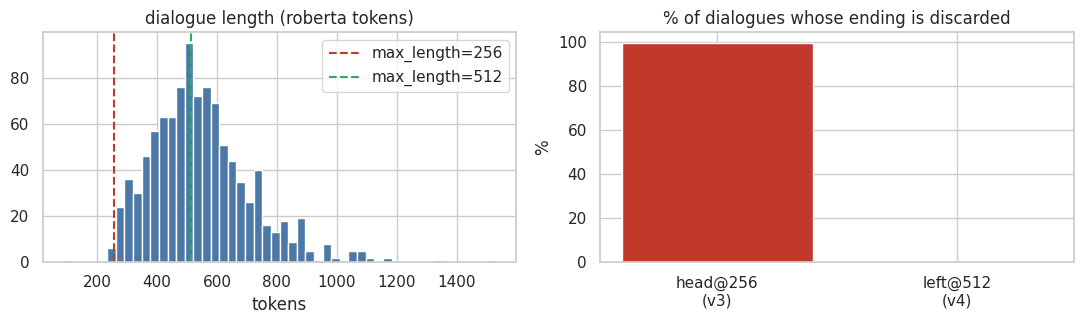

In [5]:
# Quantify truncation loss with the real tokenizer (roberta-base as reference).
_tk = AutoTokenizer.from_pretrained("roberta-base")
# We deliberately measure UNtruncated lengths here, so lift the soft cap that
# would otherwise emit a "sequence longer than model max length" warning.
# Every real call below passes an explicit max_length, so this is inert.
_tk.model_max_length = 10 ** 6
lens = np.array([len(_tk.tokenize(t)) + 2 for t in df["text"]])
print(f"token length: mean {lens.mean():.0f} | median {np.median(lens):.0f} "
      f"| p90 {np.percentile(lens,90):.0f} | max {lens.max()}")
for n in (256, 384, 512):
    print(f"   exceeds {n} tokens: {(lens>n).mean():6.1%}")

lost_head = lost_left = 0
for t in df["text"]:
    tail = t.rstrip()[-60:]
    _tk.truncation_side = "right"
    if tail not in _tk.decode(_tk(t, truncation=True, max_length=256).input_ids):
        lost_head += 1
    _tk.truncation_side = "left"
    if tail not in _tk.decode(_tk(t, truncation=True,
                                  max_length=CONFIG["max_length"]).input_ids):
        lost_left += 1
_tk.truncation_side = "right"

n = len(df)
print(f"\nfinal 60 chars LOST, head-truncation @256  (v3): {lost_head}/{n} ({lost_head/n:.1%})")
print(f"final 60 chars LOST, left-truncation @{CONFIG['max_length']} (v4): {lost_left}/{n} ({lost_left/n:.1%})")
print("\n-> v3 trained on text that does not contain the answer. This is the "
      "single largest defect and fixing it is expected to dominate every other change.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(lens, bins=50, color="#4C78A8")
for n_, c in [(256, "#C0392B"), (512, "#27AE60")]:
    ax[0].axvline(n_, color=c, ls="--", label=f"max_length={n_}")
ax[0].set_title("dialogue length (roberta tokens)"); ax[0].set_xlabel("tokens"); ax[0].legend()
ax[1].bar(["head@256\n(v3)", f"left@{CONFIG['max_length']}\n(v4)"],
          [100*lost_head/len(df), 100*lost_left/len(df)], color=["#C0392B", "#27AE60"])
ax[1].set_title("% of dialogues whose ending is discarded"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()


## 3. Stratified 70/15/15 split (before any augmentation)


In [6]:
def stratified_split(frame, seed=SEED):
    """Two-stage stratified split on the joint binary x modifier stratum.
    Falls back to binary-only stratification if a joint stratum is too small
    for scikit-learn to place in every split."""
    strat = frame["stratum"]
    use = strat if strat.value_counts().min() >= 3 else frame["binary_label"]
    if use is not strat:
        print("  [note] a joint stratum has <3 rows - stratifying on binary_label only")
    tr, tmp = train_test_split(frame, train_size=CONFIG["train_frac"],
                               random_state=seed, shuffle=True, stratify=use)
    rel = CONFIG["val_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
    use2 = tmp["stratum"] if tmp["stratum"].value_counts().min() >= 2 else tmp["binary_label"]
    va, te = train_test_split(tmp, train_size=rel, random_state=seed,
                              shuffle=True, stratify=use2)
    return (tr.reset_index(drop=True), va.reset_index(drop=True), te.reset_index(drop=True))

train_df, val_df, test_df = stratified_split(df)
train_df_pre_aug = train_df.copy()          # kept for the audit table below

print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")
print("\nstratum distribution per split")
dist = pd.DataFrame({
    "train": train_df["stratum"].value_counts(),
    "val":   val_df["stratum"].value_counts(),
    "test":  test_df["stratum"].value_counts(),
}).fillna(0).astype(int)
dist["total"] = dist.sum(axis=1)
print(dist.to_string())

if CONFIG["FAST_DEV_RUN"]:
    train_df = train_df.sample(n=min(120, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df   = val_df.sample(n=min(40, len(val_df)),   random_state=SEED).reset_index(drop=True)
    test_df  = test_df.sample(n=min(40, len(test_df)),  random_state=SEED).reset_index(drop=True)
    train_df_pre_aug = train_df.copy()
    print("\n[FAST_DEV_RUN] subsampled:", len(train_df), len(val_df), len(test_df))


train 711 | val 153 | test 153

stratum distribution per split
                 train  val  test  total
stratum                                 
yes|none           459   99    99    657
no|none            150   32    32    214
yes|deferred        47   11    10     68
no|deferred         40    8     9     57
yes|conditional      9    2     2     13
no|conditional       6    1     1      8


## 3b. Idea 4 — Data Augmentation Suite

**The label-safety argument.** The annotation guideline defines the label purely
from the Persuadee's words:

> *"Only use what the Persuadee explicitly says."*
> *"The Persuader's own claims about donating don't count."*

So augmenting **only `[Persuader]` turns cannot change the gold label** — the
spans the annotator read are left byte-identical. That is the core repair to
v3, which perturbed the whole dialogue (Persuadee turns included) at
`alpha=0.15` and could delete the very sentence carrying the commitment.

Applied to the **training split only**, after the split, so nothing synthetic
reaches val/test.



In [7]:
_TURN_RE = re.compile(r"(\[Persuader\]|\[Persuadee\])")

def split_turns(text):
    """-> (head, [(marker, content), ...]) preserving every character."""
    parts = _TURN_RE.split(text)
    head, turns = parts[0], []
    for i in range(1, len(parts) - 1, 2):
        turns.append((parts[i], parts[i + 1]))
    if len(parts) % 2 == 0 and len(parts) > 1:      # trailing marker, no content
        turns.append((parts[-1], ""))
    return head, turns

def join_turns(head, turns):
    return head + "".join(m + c for m, c in turns)

# Words that carry intent/negation/temporal semantics: never altered.
PROTECTED = {
    "if","unless","provided","condition","conditional","after","once","later",
    "when","then","next","eventually","promise","will","would","could","might",
    "may","maybe","paycheck","payday","month","week","tomorrow","soon","today",
    "not","no","never","dont","don't","wont","won't","cant","can't","cannot",
    "donate","donation","donating","give","giving","money","charity","pledge",
    "yes","yeah","sure","agree","agreed","ok","okay","commit","match","dollar",
    "dollars","cent","cents","amount","payment","hit","task","bonus",
}

SYNONYMS = {
    "good":["nice","fine","decent"], "great":["wonderful","fantastic","excellent"],
    "really":["truly","genuinely","honestly"], "think":["believe","feel"],
    "want":["wish","hope"], "help":["assist","support","aid"],
    "people":["folks","individuals"], "important":["significant","vital","crucial"],
    "cause":["mission","campaign"], "understand":["see","realize","appreciate"],
    "sorry":["apologies","regret"], "thanks":["thank you","appreciate it"],
    "kids":["children","youngsters"], "children":["kids","youngsters"],
    "families":["households"], "problem":["issue","trouble"],
    "talk":["chat","speak"], "guess":["suppose","reckon"], "job":["work","position"],
    "busy":["swamped","occupied"], "hard":["difficult","tough"],
    "many":["numerous","plenty of"], "big":["large","sizable"],
    "small":["little","modest"], "world":["globe","planet"],
    "poor":["impoverished","needy"], "food":["meals","nourishment"],
    "water":["clean water","drinking water"], "school":["schooling","education"],
    "health":["wellbeing","healthcare"], "life":["lives","livelihood"],
    "day":["daily"], "years":["yrs"], "very":["extremely","quite"],
    "lot":["great deal","bunch"], "nice":["pleasant","lovely"],
    "happy":["glad","pleased"], "sad":["unhappy","upset"],
    "work":["labor","effort"], "start":["begin","kick off"],
    "learn":["find out","discover"], "know":["am aware","understand"],
    "make":["create","produce"], "use":["utilize","employ"],
    "need":["require"], "place":["location","spot"], "time":["period"],
    "story":["account","tale"], "hear":["listen to"], "look":["seem","appear"],
    "organization":["group","body"], "program":["initiative","scheme"],
    "support":["back","stand behind"], "impact":["effect","difference"],
    "today":["right now"], "everyone":["everybody"], "always":["consistently"],
}

def _locked(tok):
    return tok.strip(".,!?;:\"'()").lower() in PROTECTED

def _syn(tok):
    core = tok.strip(".,!?;:\"'()")
    opts = SYNONYMS.get(core.lower())
    if not opts:
        return None
    rep = random.choice(opts)
    if core[:1].isupper():
        rep = rep[:1].upper() + rep[1:]
    return tok.replace(core, rep, 1)

def _aug_words(words, alpha):
    """Apply one randomly chosen EDA op at intensity alpha. Protected words are
    never replaced, deleted, or moved."""
    if len(words) < 6:
        return words
    n_ops = max(1, int(alpha * len(words)))
    free = [i for i, w in enumerate(words) if not _locked(w) and w.strip()]
    if not free:
        return words
    out = list(words)
    op = random.choice(["synonym", "swap", "delete", "insert"])

    if op == "synonym":
        cands = [i for i in free if _syn(out[i])]
        random.shuffle(cands)
        for i in cands[:n_ops]:
            s = _syn(out[i])
            if s:
                out[i] = s
    elif op == "swap":
        for _ in range(min(n_ops, max(1, len(free) // 10))):
            if len(free) < 2:
                break
            i, j = random.sample(free, 2)
            out[i], out[j] = out[j], out[i]
    elif op == "delete":
        drop = set(random.sample(free, min(n_ops, max(1, len(free) // 8))))
        out = [w for k, w in enumerate(out) if k not in drop]
    else:  # insert a synonym of an existing free word
        cands = [i for i in free if _syn(out[i])]
        for _ in range(min(n_ops, max(1, len(free) // 12))):
            if not cands:
                break
            s = _syn(out[random.choice(cands)])
            if s:
                out.insert(random.randrange(len(out) + 1), s)
    return out

def augment_text(text, alpha, seed):
    """Return an augmented dialogue, or None if nothing changed.
    Only [Persuader] turn CONTENT is touched; every [Persuadee] character and
    every speaker marker is preserved exactly."""
    random.seed(seed)
    head, turns = split_turns(text)
    if not turns:
        return None
    new_turns, changed = [], False
    for marker, content in turns:
        if CONFIG["aug_persuader_only"] and marker != "[Persuader]":
            new_turns.append((marker, content))
            continue
        words = content.split(" ")
        aug = _aug_words(words, alpha)
        new_content = " ".join(aug)
        if new_content != content:
            changed = True
        new_turns.append((marker, new_content))
    if not changed:
        return None
    return join_turns(head, new_turns)

def stable_seed(*parts):
    h = hashlib.md5("||".join(map(str, parts)).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

print("augmentation helpers ready")


augmentation helpers ready


In [8]:
def build_augmented(frame, cfg, seed=SEED):
    """Grow only the starved modifier strata toward `aug_targets`.
    `none` strata are never augmented, so the binary prior stays ~unchanged."""
    if not cfg["use_augmentation"]:
        print("augmentation disabled")
        return frame.reset_index(drop=True), pd.DataFrame()

    rows, report = [], []
    for stratum, sub in frame.groupby("stratum", sort=False):
        mod = stratum.split("|")[1]
        target = cfg["aug_targets"].get(mod)
        if not target or len(sub) == 0:
            report.append((stratum, len(sub), len(sub), 0))
            continue
        copies = min(cfg["aug_max_copies"], max(0, math.ceil(target / len(sub)) - 1))
        made = 0
        for ridx, row in sub.iterrows():
            for k in range(copies):
                txt = None
                for attempt in range(3):              # retry until it differs
                    txt = augment_text(row["text"], cfg["aug_alpha"],
                                       stable_seed(row["text"], k, attempt))
                    if txt:
                        break
                if not txt:
                    continue
                nr = row.copy(); nr["text"] = txt; nr["is_augmented"] = True
                rows.append(nr); made += 1
        report.append((stratum, len(sub), len(sub) + made, made))

    rep = pd.DataFrame(report, columns=["stratum", "before", "after", "added"]) \
            .sort_values("stratum").reset_index(drop=True)
    if not rows:
        out = frame.copy()
    else:
        out = pd.concat([frame, pd.DataFrame(rows)], ignore_index=True)
    out["is_augmented"] = out.get("is_augmented", False)
    out["is_augmented"] = out["is_augmented"].fillna(False).astype(bool)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True), rep

train_df["is_augmented"] = False
train_df, aug_report = build_augmented(train_df, CONFIG)

print(f"train rows: {len(train_df_pre_aug)} -> {len(train_df)}")
if len(aug_report):
    print("\nper-stratum augmentation")
    print(aug_report.to_string(index=False))

print("\nbinary prior  (the v3 bug was shifting this):")
prior = pd.DataFrame({
    "before": train_df_pre_aug["binary_label"].value_counts(normalize=True),
    "after":  train_df["binary_label"].value_counts(normalize=True),
    "val":    val_df["binary_label"].value_counts(normalize=True),
    "test":   test_df["binary_label"].value_counts(normalize=True),
}).round(3)
print(prior.to_string())

print("\nmodifier distribution:")
print(pd.DataFrame({
    "before": train_df_pre_aug["modifier"].value_counts(),
    "after":  train_df["modifier"].value_counts(),
}).fillna(0).astype(int).to_string())


train rows: 711 -> 1092

per-stratum augmentation
        stratum  before  after  added
 no|conditional       6     54     48
    no|deferred      40    160    120
        no|none     150    150      0
yes|conditional       9     81     72
   yes|deferred      47    188    141
       yes|none     459    459      0

binary prior  (the v3 bug was shifting this):
              before  after    val   test
binary_label                             
yes            0.724  0.667  0.732  0.725
no             0.276  0.333  0.268  0.275

modifier distribution:
             before  after
modifier                  
none            609    609
deferred         87    348
conditional      15    135


In [9]:
# ---- Augmentation QA: prove no Persuadee character was altered -------------
def persuadee_signature(text):
    _h, turns = split_turns(text)
    return "||".join(c for m, c in turns if m == "[Persuadee]")

aug_rows = train_df[train_df["is_augmented"]]
print(f"checking {len(aug_rows)} augmented rows...")

by_sig = {t: persuadee_signature(t) for t in train_df_pre_aug["text"]}
orig_sigs = set(by_sig.values())

bad_sig = sum(1 for t in aug_rows["text"] if persuadee_signature(t) not in orig_sigs)
identical = int(aug_rows["text"].isin(set(train_df_pre_aug["text"])).sum())
dupes = int(aug_rows["text"].duplicated().sum())

print(f"  Persuadee text altered : {bad_sig}   (must be 0)")
print(f"  identical to an original: {identical}   (must be 0)")
print(f"  duplicate augmentations : {dupes}")
assert bad_sig == 0, "augmentation modified Persuadee text - label safety violated"
assert identical == 0, "augmentation produced an exact copy of an original row"
print("\nOK - every augmented row differs from its source and preserves all "
      "Persuadee text verbatim, so the gold label is provably unchanged.")

if len(aug_rows):
    ex = aug_rows.iloc[0]
    src = train_df_pre_aug[train_df_pre_aug["modifier"] == ex["modifier"]].iloc[0]
    print("\n--- example augmented Persuader turn ---")
    _h, t_ = split_turns(ex["text"])
    for m, c in t_[:4]:
        print(f"  {m} {c.strip()[:110]}")


checking 381 augmented rows...
  Persuadee text altered : 0   (must be 0)
  identical to an original: 0   (must be 0)
  duplicate augmentations : 0

OK - every augmented row differs from its source and preserves all Persuadee text verbatim, so the gold label is provably unchanged.

--- example augmented Persuader turn ---
  [Persuader] Hi how are you this daily ?
  [Persuadee] Hey, I'm doing great, how are you?
  [Persuader] I am very good. Glad to be doing this survey because it is for a good cause (Save the children) Do ? agree you
  [Persuadee] Oh absolutely! I think it's very important to donate to charities.


## 4. Tokenisation, speaker roles, and left truncation


In [10]:
ROLE_PERSUADER, ROLE_PERSUADEE, ROLE_SPECIAL = 0, 1, 2
_ROLE_OF = {"[Persuader]": ROLE_PERSUADER, "[Persuadee]": ROLE_PERSUADEE}

class DialogueDataset(Dataset):
    def __init__(self, frame):
        self.text = frame["text"].tolist()
        self.b    = frame["binary_id"].tolist()
        self.m    = frame["modifier_id"].tolist()
    def __len__(self):  return len(self.text)
    def __getitem__(self, i):
        return {"text": self.text[i], "binary_id": self.b[i], "modifier_id": self.m[i]}

def batch_role_ids(texts, offsets):
    """Map each token to the speaker whose turn it falls in, via char offsets.
    Works for BPE and SentencePiece alike, and stays correct under left
    truncation because offsets index the ORIGINAL string."""
    out = []
    for text, toks in zip(texts, offsets.tolist()):
        bounds = sorted((m.start(), _ROLE_OF[m.group()])
                        for m in _TURN_RE.finditer(text))
        roles = []
        for cs, ce in toks:
            if cs == 0 and ce == 0:
                roles.append(ROLE_SPECIAL); continue
            r = ROLE_SPECIAL
            for bpos, brole in bounds:
                if bpos <= cs: r = brole
                else: break
            roles.append(r)
        out.append(roles)
    return torch.tensor(out, dtype=torch.long)

def make_collate(tokenizer, max_length, use_roles):
    def fn(batch):
        texts = [b["text"] for b in batch]
        kw = dict(padding=True, truncation=True, max_length=max_length,
                  return_tensors="pt")
        enc, roles = None, None
        if use_roles:
            try:
                enc = tokenizer(texts, return_offsets_mapping=True, **kw)
                roles = batch_role_ids(texts, enc.pop("offset_mapping"))
            except Exception:
                enc = None
        if enc is None:
            enc = tokenizer(texts, **kw)
        if roles is not None:
            enc["role_ids"] = roles
        enc["binary_labels"]   = torch.tensor([b["binary_id"]   for b in batch])
        enc["modifier_labels"] = torch.tensor([b["modifier_id"] for b in batch])
        return enc
    return fn

def load_tokenizer(hf_id):
    tok = AutoTokenizer.from_pretrained(hf_id, use_fast=True)
    tok.truncation_side = CONFIG["truncation_side"]      # <- FIX 1
    return tok

_t = load_tokenizer("roberta-base")
print("truncation_side:", _t.truncation_side, "| max_length:", CONFIG["max_length"])
_demo = _t(df["text"].iloc[0], truncation=True, max_length=CONFIG["max_length"])
print("kept tail of dialogue 0:\n  ...", _t.decode(_demo.input_ids)[-160:].replace("\n", " "))


truncation_side: left | max_length: 512
kept tail of dialogue 0:
  ... es, I agree as well, there needs to be more help from everybody  [Persuadee] yes i am thank full from you and if i can i will help a more and more with them</s>


## 5. Two-head model


In [11]:
class TwoHeadClassifier(nn.Module):
    """Shared encoder -> (optional) speaker-role embedding -> masked mean-pool
    -> binary head (2) + modifier head (3)."""
    def __init__(self, hf_id, n_binary, n_modifier, use_roles=True, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(hf_id)
        h = self.encoder.config.hidden_size
        self.use_roles = use_roles
        if use_roles:
            self.role_emb = nn.Embedding(3, h)
            nn.init.normal_(self.role_emb.weight, std=0.02)
        self.dropout       = nn.Dropout(dropout)
        self.binary_head   = nn.Linear(h, n_binary)
        self.modifier_head = nn.Linear(h, n_modifier)

    def forward(self, input_ids, attention_mask, role_ids=None, **kw):
        enc_kw = {k: v for k, v in kw.items() if k == "token_type_ids"}
        hs = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                          **enc_kw).last_hidden_state
        if self.use_roles and role_ids is not None:
            hs = hs + self.role_emb(role_ids)
        m = attention_mask.unsqueeze(-1).float()
        pooled = (hs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        return self.binary_head(pooled), self.modifier_head(pooled)

print("model class ready")


model class ready


## 6. Class weights

Weighting and augmentation must be **one** correction, not two stacked ones —
stacking them is what over-rotates a model toward minority classes. So each
head takes its weights from the distribution that augmentation actually left
behind:

* **binary** — augmentation is *not* a binary-balancing tool here (only the
  `deferred`/`conditional` strata grow). Its weights therefore come from the
  **pre-augmentation** split, i.e. the true prior, so the incidental drift
  augmentation causes is not amplified.
* **modifier** — augmentation *is* the balancing tool. Its weights come from
  the **post-augmentation** split, so they only correct the imbalance that
  remains. They are far gentler than the pre-augmentation weights would be
  (`conditional` drops from ~16x to ~3x), which is exactly the intent.



In [12]:
def inv_freq(ids, n):
    c = np.bincount(np.asarray(ids), minlength=n).astype(float)
    c[c == 0] = 1.0
    return torch.tensor(c.sum() / (n * c), dtype=torch.float)

n_b, n_m = len(CONFIG["binary_classes"]), len(CONFIG["modifier_classes"])

# binary: true prior (pre-augmentation)
binary_w = inv_freq(train_df_pre_aug["binary_id"].values, n_b)

# modifier: residual imbalance (post-augmentation)
if CONFIG["modifier_on_all_rows"]:
    modifier_w = inv_freq(train_df["modifier_id"].values, n_m)
    src = "all training rows, post-aug"
else:
    sub = train_df[train_df["binary_label"] == "yes"]
    modifier_w = inv_freq(sub["modifier_id"].values, n_m)
    src = "yes-only rows, post-aug"

print("binary weights (pre-aug prior) :",
      dict(zip(CONFIG["binary_classes"], np.round(binary_w.numpy(), 3))))
print(f"modifier weights ({src}):",
      dict(zip(CONFIG["modifier_classes"], np.round(modifier_w.numpy(), 3))))
print("\nfor contrast, modifier weights WITHOUT augmentation would have been:",
      dict(zip(CONFIG["modifier_classes"],
               np.round(inv_freq(train_df_pre_aug["modifier_id"].values, n_m).numpy(), 3))))
print("-> augmentation absorbs most of the imbalance; the weights only finish the job.")


binary weights (pre-aug prior) : {'no': np.float32(1.814), 'yes': np.float32(0.69)}
modifier weights (all training rows, post-aug): {'none': np.float32(0.598), 'deferred': np.float32(1.046), 'conditional': np.float32(2.696)}

for contrast, modifier weights WITHOUT augmentation would have been: {'none': np.float32(0.389), 'deferred': np.float32(2.724), 'conditional': np.float32(15.8)}
-> augmentation absorbs most of the imbalance; the weights only finish the job.


## 7. Train / evaluate


In [15]:
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    bt, bp, mt, mp, probs = [], [], [], [], []
    yes_i = CONFIG["binary_classes"].index("yes")
    with torch.no_grad():
        for batch in loader:
            bl = batch.pop("binary_labels"); ml = batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            blog, mlog = model(**batch)
            p_yes = torch.softmax(blog, -1)[:, yes_i].cpu().numpy()
            probs.extend(p_yes)
            bp.extend((p_yes >= threshold).astype(int) if yes_i == 1
                      else (p_yes < threshold).astype(int))
            mp.extend(mlog.argmax(-1).cpu().numpy())
            bt.extend(bl.numpy()); mt.extend(ml.numpy())

    n_b, n_m = len(CONFIG["binary_classes"]), len(CONFIG["modifier_classes"])
    out = {
        "binary_accuracy":  accuracy_score(bt, bp),
        "binary_macro_f1":  f1_score(bt, bp, average="macro", labels=list(range(n_b)), zero_division=0),
        "binary_yes_f1":    f1_score(bt, bp, pos_label=yes_i, average="binary", zero_division=0),
        "modifier_macro_f1": f1_score(mt, mp, average="macro", labels=list(range(n_m)), zero_division=0),
        "binary_true": bt, "binary_pred": bp,
        "modifier_true": mt, "modifier_pred": mp, "p_yes": probs,
    }
    idx = [i for i, t in enumerate(bt) if t == yes_i]
    out["modifier_macro_f1_given_yes"] = (
        f1_score([mt[i] for i in idx], [mp[i] for i in idx], average="macro",
                 labels=list(range(n_m)), zero_division=0) if idx else 0.0)
    out["selection_score"] = 0.5 * (out["binary_macro_f1"] + out["modifier_macro_f1"])
    return out


def train_encoder(spec):
    name, hf_id = spec["name"], spec["hf_id"]
    lr    = spec.get("lr", CONFIG["lr"])
    bs    = spec.get("batch_size", CONFIG["batch_size"])
    wu    = spec.get("warmup_ratio", CONFIG["warmup_ratio"])
    epochs = 1 if CONFIG["FAST_DEV_RUN"] else CONFIG["num_epochs"]

    print("=" * 68); print(f"Training {name} ({hf_id})"); print("=" * 68)
    tok = load_tokenizer(hf_id)
    coll = make_collate(tok, CONFIG["max_length"], CONFIG["use_speaker_roles"])

    dl_tr = DataLoader(DialogueDataset(train_df), batch_size=bs, shuffle=True,  collate_fn=coll)
    dl_va = DataLoader(DialogueDataset(val_df),   batch_size=CONFIG["eval_batch_size"], collate_fn=coll)
    dl_te = DataLoader(DialogueDataset(test_df),  batch_size=CONFIG["eval_batch_size"], collate_fn=coll)

    model = TwoHeadClassifier(hf_id, len(CONFIG["binary_classes"]),
                              len(CONFIG["modifier_classes"]),
                              CONFIG["use_speaker_roles"]).to(DEVICE)

    bce = nn.CrossEntropyLoss(weight=binary_w.to(DEVICE)   if CONFIG["use_class_weights"] else None,
                              label_smoothing=CONFIG["label_smoothing"])
    mce = nn.CrossEntropyLoss(weight=modifier_w.to(DEVICE) if CONFIG["use_class_weights"] else None,
                              label_smoothing=CONFIG["label_smoothing"])

    opt = torch.optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total = max(1, len(dl_tr) * epochs)
    sch = get_linear_schedule_with_warmup(opt, int(wu * total), total)

    ckpt = os.path.join(CONFIG["out_dir"], f"{name}_best.pt")
    best, bad, hist = -1.0, 0, []

    for ep in range(1, epochs + 1):
        model.train(); tot = 0.0; nb = 0
        for batch in tqdm(dl_tr, desc=f"  epoch {ep}/{epochs}", leave=False):
            bl = batch.pop("binary_labels").to(DEVICE)
            ml = batch.pop("modifier_labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            blog, mlog = model(**batch)

            loss_b = bce(blog, bl)
            if CONFIG["modifier_on_all_rows"]:
                loss_m = mce(mlog, ml)
            else:
                yes_i = CONFIG["binary_classes"].index("yes")
                msk = bl == yes_i
                loss_m = mce(mlog[msk], ml[msk]) if msk.any() else torch.tensor(0.0, device=DEVICE)
            loss = CONFIG["binary_loss_weight"] * loss_b + CONFIG["modifier_loss_weight"] * loss_m
            if not torch.isfinite(loss):
                continue
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            opt.step(); sch.step()
            tot += loss.item(); nb += 1

        va = evaluate(model, dl_va, DEVICE)
        hist.append({"epoch": ep, "train_loss": tot / max(nb, 1),
                     "val_binary_macro_f1": va["binary_macro_f1"],
                     "val_modifier_macro_f1": va["modifier_macro_f1"],
                     "val_score": va["selection_score"]})
        print(f"  epoch {ep:2d}: loss={tot/max(nb,1):.4f} "
              f"val_bin_macroF1={va['binary_macro_f1']:.4f} "
              f"val_mod_macroF1={va['modifier_macro_f1']:.4f} "
              f"score={va['selection_score']:.4f}")

        if va["selection_score"] > best:
            best, bad = va["selection_score"], 0
            torch.save(model.state_dict(), ckpt)
            print("    -> new best, checkpoint saved")
        else:
            bad += 1
            if bad >= CONFIG["early_stopping_patience"]:
                print("    -> early stop"); break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))

    # threshold tuned on val for binary macro-F1
    va = evaluate(model, dl_va, DEVICE)
    yes_i = CONFIG["binary_classes"].index("yes")
    best_t, best_f1 = 0.5, -1
    for t in np.arange(0.20, 0.81, 0.05):
        pred = [(1 if p >= t else 0) if yes_i == 1 else (0 if p >= t else 1)
                for p in va["p_yes"]]
        f1 = f1_score(va["binary_true"], pred, average="macro",
                      labels=[0, 1], zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    print(f"  tuned threshold={best_t:.2f} (val binary macro-F1={best_f1:.4f})")

    te_05 = evaluate(model, dl_te, DEVICE, 0.5)
    te_tn = evaluate(model, dl_te, DEVICE, best_t)

    del model; gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return {"name": name, "history": hist, "threshold": best_t,
            "test": te_05, "test_tuned": te_tn}


In [16]:
results = {}
encoders = CONFIG["encoders"][:1] if CONFIG["FAST_DEV_RUN"] else CONFIG["encoders"]

for spec in encoders:
    try:
        results[spec["name"]] = train_encoder(spec)
    except Exception as exc:
        # One encoder failing to download must not kill the whole run.
        print(f"\n[SKIPPED] {spec['name']}: {type(exc).__name__}: {exc}\n")

print("\ntrained:", list(results.keys()))
assert results, "no encoder trained successfully - check internet / model ids"


Training roberta-base (roberta-base)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/12:   0%|          | 0/137 [00:00<?, ?it/s]

...

  epoch  7: loss=0.3453 val_bin_macroF1=0.7305 val_mod_macroF1=0.3405 score=0.5355


  epoch 8/12:   0%|          | 0/137 [00:00<?, ?it/s]

  epoch  8: loss=0.3316 val_bin_macroF1=0.7777 val_mod_macroF1=0.3062 score=0.5420


  epoch 9/12:   0%|          | 0/137 [00:00<?, ?it/s]

  epoch  9: loss=0.3236 val_bin_macroF1=0.7305 val_mod_macroF1=0.3073 score=0.5189
    -> early stop
  tuned threshold=0.80 (val binary macro-F1=0.8127)

trained: ['roberta-base', 'deberta-v3-base', 'todbert']


## 8. Results


In [17]:
# Majority baseline on the SAME test split
maj_b = int(train_df["binary_id"].mode()[0])
maj_m = int(train_df["modifier_id"].mode()[0])
bt = test_df["binary_id"].tolist(); mt = test_df["modifier_id"].tolist()
bp = [maj_b] * len(bt); mp = [maj_m] * len(mt)
yes_i = CONFIG["binary_classes"].index("yes")

baseline = {
    "model": "majority baseline",
    "binary_accuracy":   accuracy_score(bt, bp),
    "binary_macro_f1":   f1_score(bt, bp, average="macro", labels=[0, 1], zero_division=0),
    "binary_yes_f1":     f1_score(bt, bp, pos_label=yes_i, average="binary", zero_division=0),
    "modifier_macro_f1": f1_score(mt, mp, average="macro", labels=[0, 1, 2], zero_division=0),
}

rows = [baseline]
for name, r in results.items():
    for tag, key in (("@0.5", "test"), ("@tuned", "test_tuned")):
        t = r[key]
        rows.append({"model": f"{name} {tag}",
                     "binary_accuracy":   t["binary_accuracy"],
                     "binary_macro_f1":   t["binary_macro_f1"],
                     "binary_yes_f1":     t["binary_yes_f1"],
                     "modifier_macro_f1": t["modifier_macro_f1"]})

summary_df = pd.DataFrame(rows).round(4)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(CONFIG["out_dir"], "v4_test_results.csv"), index=False)

best_row = summary_df.iloc[1:].sort_values("binary_macro_f1", ascending=False).head(1)
if len(best_row):
    d = float(best_row["binary_macro_f1"].iloc[0]) - baseline["binary_macro_f1"]
    print(f"\nbest binary macro-F1 vs majority baseline: {d:+.4f}")


                 model  binary_accuracy  binary_macro_f1  binary_yes_f1  modifier_macro_f1
     majority baseline           0.7255           0.4205         0.8409             0.3075
     roberta-base @0.5           0.8824           0.8424         0.9217             0.3231
   roberta-base @tuned           0.8758           0.8351         0.9170             0.3231
  deberta-v3-base @0.5           0.2745           0.2154         0.0000             0.3075
deberta-v3-base @tuned           0.7255           0.4205         0.8409             0.3075
          todbert @0.5           0.8301           0.7592         0.8898             0.3457
        todbert @tuned           0.8170           0.7736         0.8727             0.3457

best binary macro-F1 vs majority baseline: +0.4219


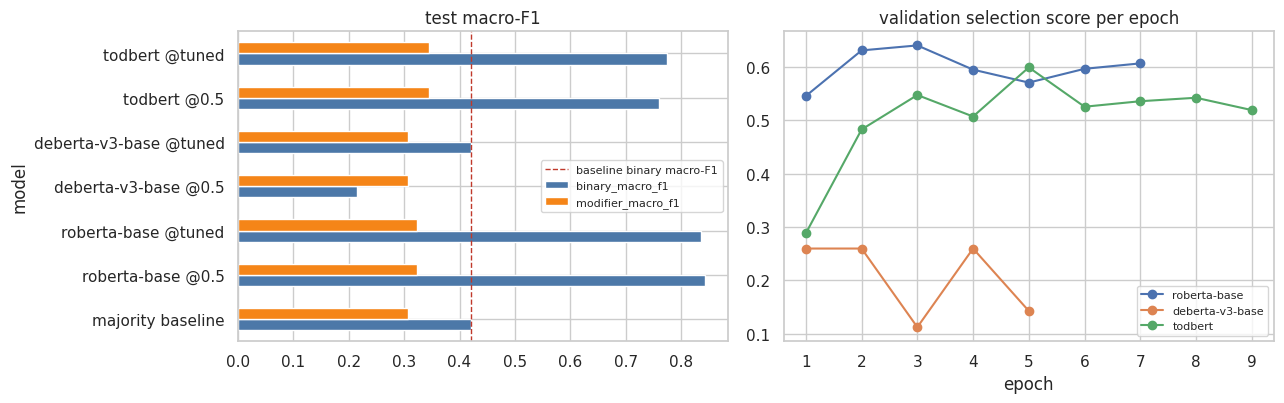

In [18]:
if len(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    plot_df = summary_df.set_index("model")[["binary_macro_f1", "modifier_macro_f1"]]
    plot_df.plot(kind="barh", ax=axes[0], color=["#4C78A8", "#F58518"])
    axes[0].axvline(baseline["binary_macro_f1"], color="#C0392B", ls="--", lw=1,
                    label="baseline binary macro-F1")
    axes[0].set_title("test macro-F1"); axes[0].legend(fontsize=8)

    for name, r in results.items():
        h = pd.DataFrame(r["history"])
        axes[1].plot(h["epoch"], h["val_score"], marker="o", label=name)
    axes[1].set_title("validation selection score per epoch")
    axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["out_dir"], "v4_results.png"), dpi=140)
    plt.show()


In [19]:
for name, r in results.items():
    t = r["test_tuned"]
    print("=" * 68); print(name); print("=" * 68)
    print("binary_label:")
    print(classification_report(t["binary_true"], t["binary_pred"],
                                target_names=CONFIG["binary_classes"], zero_division=0))
    print("modifier (all rows):")
    print(classification_report(t["modifier_true"], t["modifier_pred"],
                                target_names=CONFIG["modifier_classes"], zero_division=0))
    print(f"modifier macro-F1 | binary=yes  : {t['modifier_macro_f1_given_yes']:.4f}")
    print()


roberta-base
binary_label:
              precision    recall  f1-score   support

          no       0.83      0.69      0.75        42
         yes       0.89      0.95      0.92       111

    accuracy                           0.88       153
   macro avg       0.86      0.82      0.84       153
weighted avg       0.87      0.88      0.87       153

modifier (all rows):
              precision    recall  f1-score   support

        none       0.86      0.94      0.90       131
    deferred       0.11      0.05      0.07        19
 conditional       0.00      0.00      0.00         3

    accuracy                           0.81       153
   macro avg       0.32      0.33      0.32       153
weighted avg       0.75      0.81      0.78       153

modifier macro-F1 | binary=yes  : 0.3092

deberta-v3-base
binary_label:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00        42
         yes       0.73      1.00      0.84       111

    accu

saved: /kaggle/working/v4_confusion_matrices.png


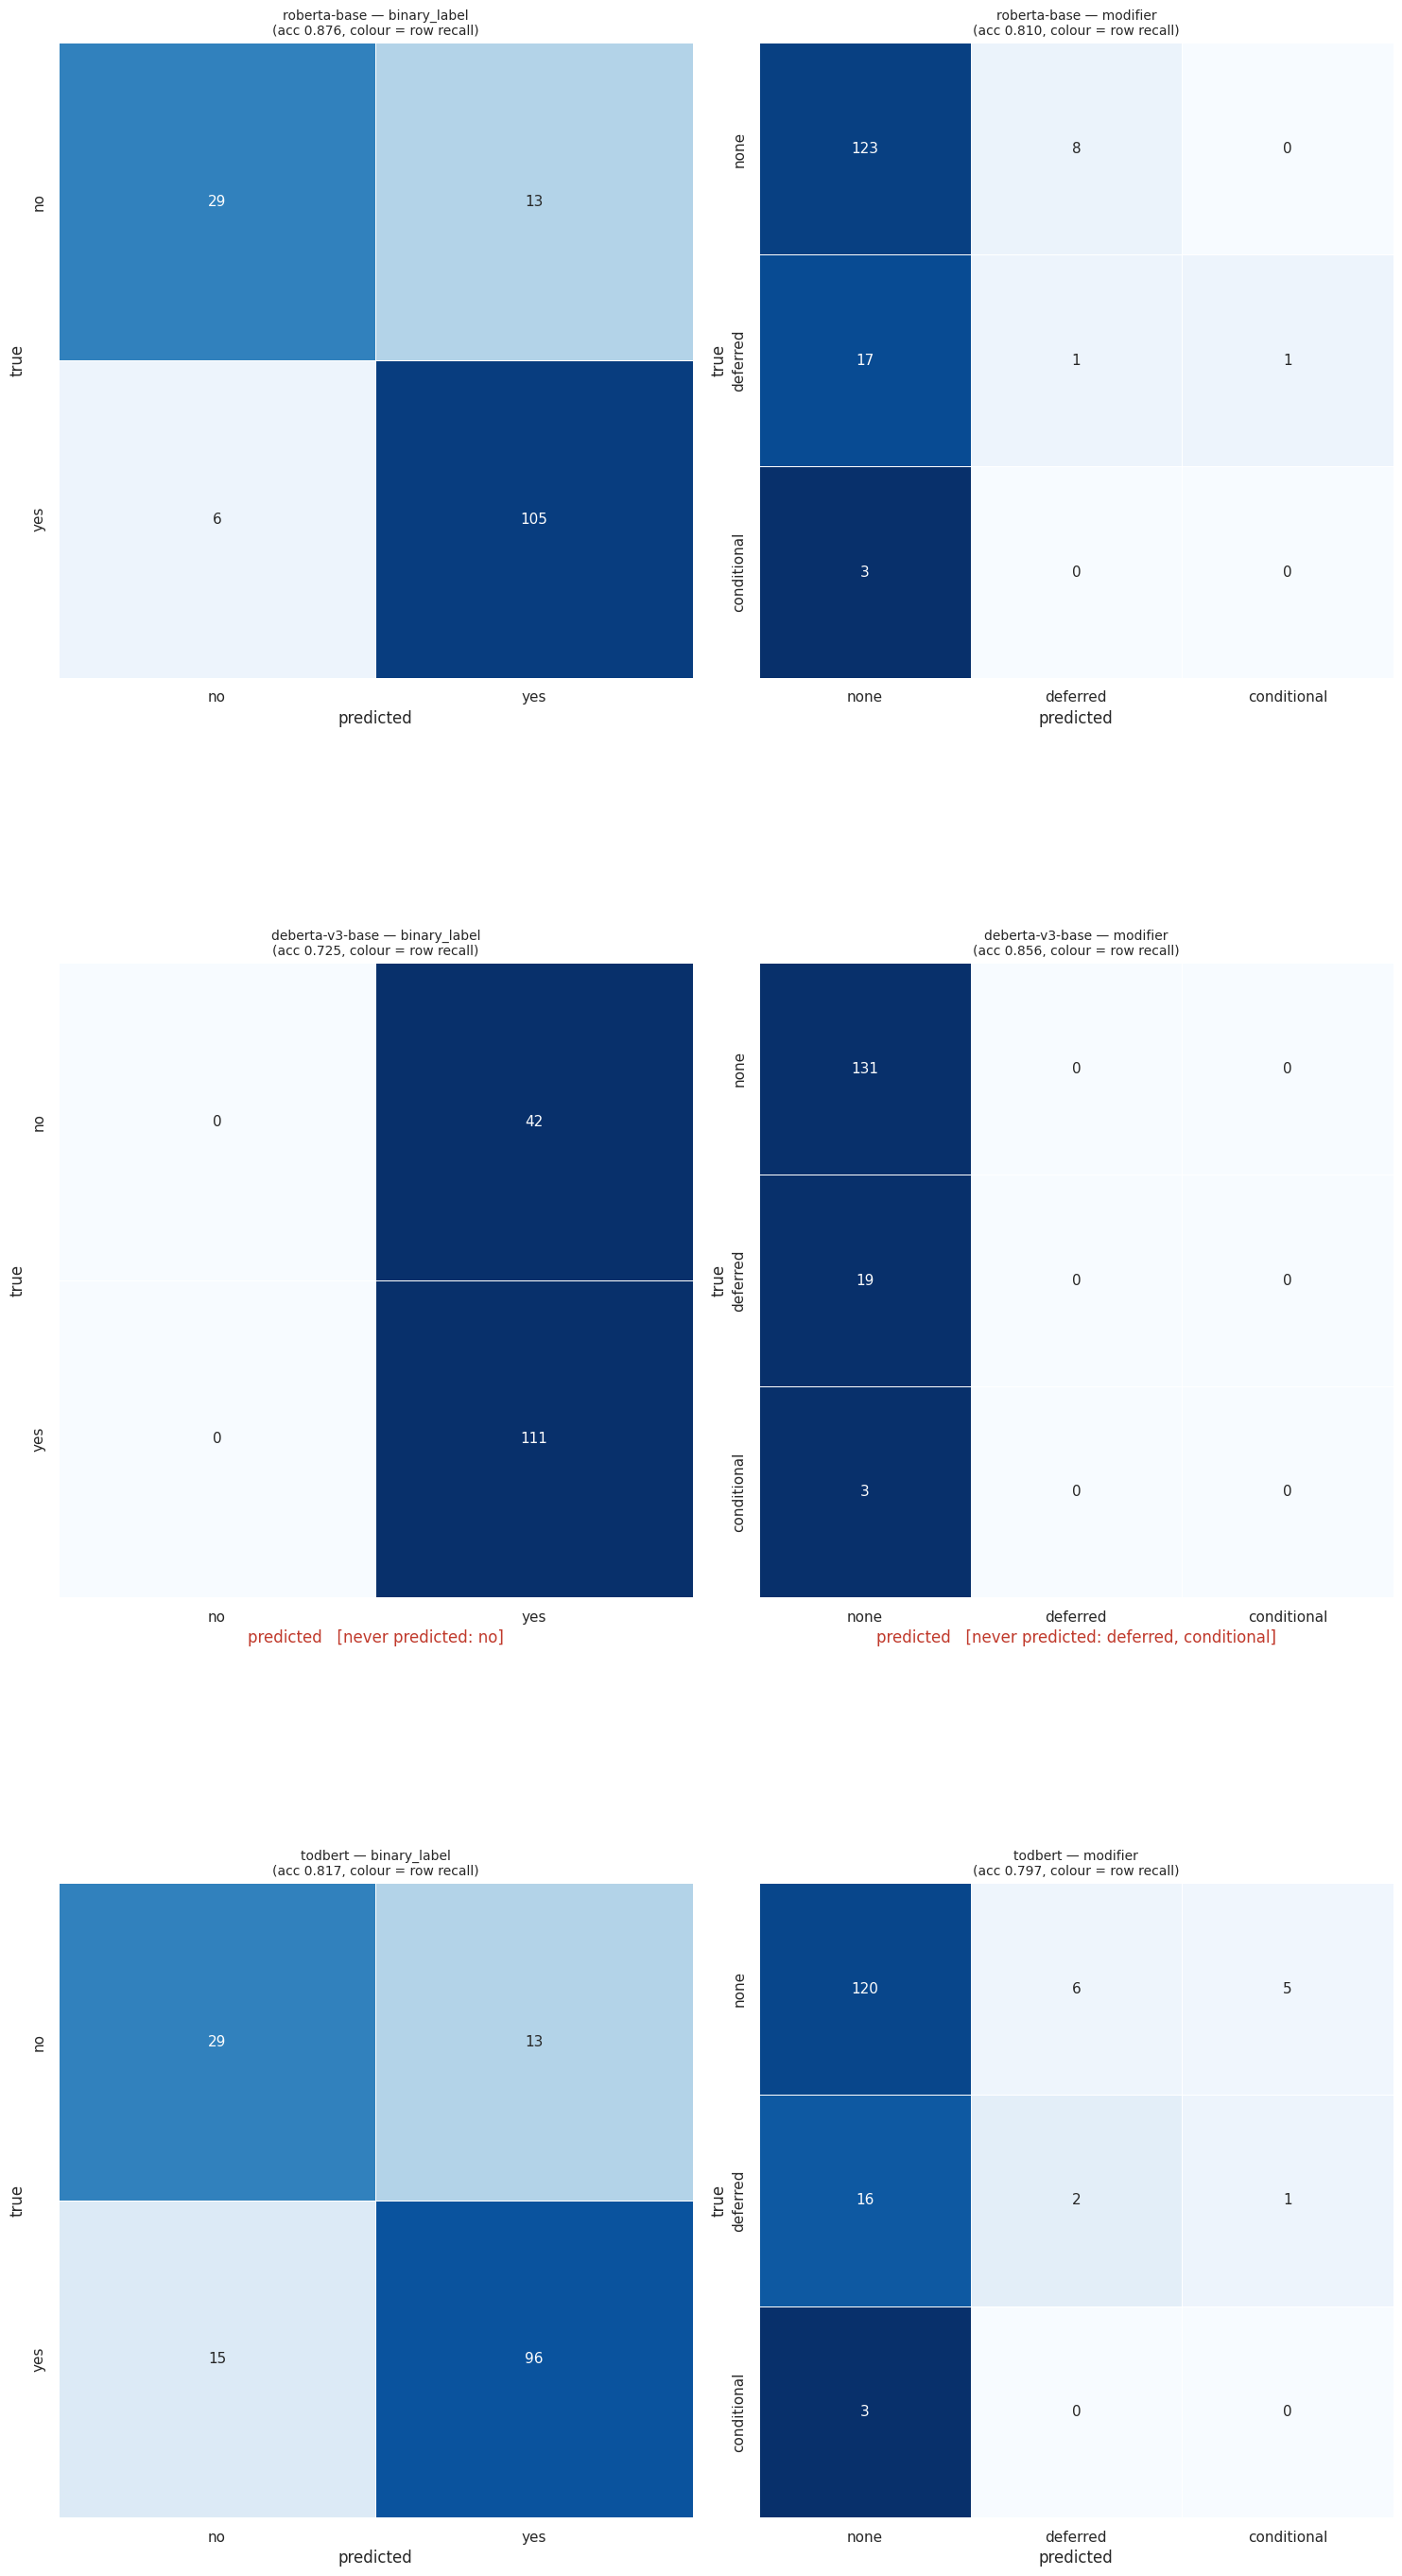


          model     head       class  support  recall
   roberta-base   binary          no       42   0.690
   roberta-base   binary         yes      111   0.946
   roberta-base modifier        none      131   0.939
   roberta-base modifier    deferred       19   0.053
   roberta-base modifier conditional        3   0.000
deberta-v3-base   binary          no       42   0.000
deberta-v3-base   binary         yes      111   1.000
deberta-v3-base modifier        none      131   1.000
deberta-v3-base modifier    deferred       19   0.000
deberta-v3-base modifier conditional        3   0.000
        todbert   binary          no       42   0.690
        todbert   binary         yes      111   0.865
        todbert modifier        none      131   0.916
        todbert modifier    deferred       19   0.105
        todbert modifier conditional        3   0.000


In [23]:
# =============================================================
# 8d. Confusion matrices — binary_label and modifier, per encoder
# =============================================================
# Counts in each cell, colour = row-normalised recall, so a bright
# off-diagonal block is a systematic confusion rather than just a big class.
CM_SPLIT = "test_tuned"          # "test" = threshold 0.5, "test_tuned" = val-tuned

b_names = CONFIG["binary_classes"]
m_names = CONFIG["modifier_classes"]

n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(15, 10 * n), squeeze=False)

for r_i, (name, res) in enumerate(results.items()):
    t = res[CM_SPLIT]
    panels = [
        ("binary_label", t["binary_true"], t["binary_pred"], b_names),
        ("modifier",     t["modifier_true"], t["modifier_pred"], m_names),
    ]
    for c_i, (title, y_true, y_pred, labels) in enumerate(panels):
        ax = axes[r_i][c_i]
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sum, out=np.zeros_like(cm, dtype=float),
                            where=row_sum != 0)

        sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                    cbar=False, square=True, linewidths=.5, linecolor="white",
                    xticklabels=labels, yticklabels=labels, ax=ax,
                    annot_kws={"fontsize": 11})
        acc = (np.array(y_true) == np.array(y_pred)).mean()
        ax.set_title(f"{name} — {title}\n(acc {acc:.3f}, colour = row recall)", fontsize=10)
        ax.set_xlabel("predicted")
        ax.set_ylabel("true")

        # flag any class the model never predicts — the classic collapse mode
        never = [labels[k] for k in range(len(labels)) if cm[:, k].sum() == 0]
        if never:
            ax.set_xlabel(f"predicted   [never predicted: {', '.join(never)}]",
                          color="#C0392B")

plt.tight_layout()
_p = os.path.join(CONFIG["out_dir"], "v4_confusion_matrices.png")
plt.savefig(_p, dpi=140, bbox_inches="tight")
print("saved:", _p)
plt.show()

# Per-class recall table — easier to read than the heatmap for the rare classes
rows = []
for name, res in results.items():
    t = res[CM_SPLIT]
    for title, y_true, y_pred, labels in [
        ("binary", t["binary_true"], t["binary_pred"], b_names),
        ("modifier", t["modifier_true"], t["modifier_pred"], m_names)]:
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
        for k, lab in enumerate(labels):
            support = int(cm[k].sum())
            rows.append({"model": name, "head": title, "class": lab,
                         "support": support,
                         "recall": round(cm[k, k] / support, 3) if support else np.nan})
print()
print(pd.DataFrame(rows).to_string(index=False))


In [24]:
# =============================================================
# 8f. Inspect the misclassified dialogues (binary head)
# =============================================================
# Same alignment guard as 8e. Adds the decision margin, because these
# predictions come from the val-tuned threshold: an error with |margin| ~ 0
# was a coin-flip, one with a large margin is a genuine content mistake.
BIN_MODEL = "roberta-base"      # any key of `results`
BIN_SPLIT = "test_tuned"        # "test" (thr 0.5) or "test_tuned"
BIN_CELLS = [("no", "yes"), ("yes", "no")]     # (true, predicted)

if BIN_MODEL not in results:
    BIN_MODEL = list(results)[0]
    print(f"[note] falling back to '{BIN_MODEL}'")

tb = results[BIN_MODEL][BIN_SPLIT]
thr = results[BIN_MODEL]["threshold"] if BIN_SPLIT == "test_tuned" else 0.5
b_names, m_names = CONFIG["binary_classes"], CONFIG["modifier_classes"]

# --- alignment guard -------------------------------------------------------
assert len(tb["binary_true"]) == len(test_df), "prediction/test_df length mismatch"
assert list(tb["binary_true"]) == test_df["binary_id"].tolist(), \
    "row order mismatch - the DataLoader must be shuffle=False for this to work"
print(f"alignment OK - {len(test_df)} test rows | decision threshold = {thr:.2f}\n")

def last_turn(text, who="[Persuadee]"):
    parts = _TURN_RE.split(text)
    out = ""
    for i in range(1, len(parts) - 1, 2):
        if parts[i] == who:
            out = parts[i + 1].strip()
    return out

ins = test_df.reset_index(drop=True).copy()
ins["binary_pred"]   = [b_names[p] for p in tb["binary_pred"]]
ins["modifier_pred"] = [m_names[p] for p in tb["modifier_pred"]]
ins["p_yes"]         = np.round(tb["p_yes"], 4)
ins["margin"]        = np.round(ins["p_yes"] - thr, 4)   # >0 -> predicted yes
ins["last_persuadee_turn"] = ins["text"].map(last_turn)
ins["n_words"]       = ins["text"].str.split().str.len()

mask = pd.Series(False, index=ins.index)
for true_lab, pred_lab in BIN_CELLS:
    mask |= (ins["binary_label"] == true_lab) & (ins["binary_pred"] == pred_lab)
errb = ins[mask].copy()
errb["confusion_cell"] = errb["binary_label"] + " -> " + errb["binary_pred"]
errb["error_type"] = np.where(errb["binary_label"] == "no",
                              "false positive (over-predicts donation)",
                              "false negative (misses a real commitment)")
# borderline = would flip if the threshold moved by <= 0.10
errb["borderline"] = errb["margin"].abs() <= 0.10

print("counts per requested cell (should match the heatmap):")
print(errb["confusion_cell"].value_counts().to_string())
print(f"\nof these, {int(errb['borderline'].sum())}/{len(errb)} are borderline "
      f"(|p_yes - threshold| <= 0.10) - i.e. a small threshold change flips them.\n")

cols = ["confusion_cell", "error_type", "p_yes", "margin", "borderline",
        "modifier", "modifier_pred", "n_words", "last_persuadee_turn", "text"]
errb = errb[cols].sort_values(["confusion_cell", "margin"],
                              key=lambda s: s.abs() if s.name == "margin" else s
                              ).reset_index(drop=True)

stem = os.path.join(CONFIG["out_dir"], f"v4_binary_errors_{BIN_MODEL}")
errb.to_csv(stem + ".csv", index=False)

with open(stem + ".txt", "w", encoding="utf-8") as fh:
    fh.write(f"Binary misclassifications - {BIN_MODEL} ({BIN_SPLIT}, threshold={thr:.2f})\n")
    fh.write(f"cells: {BIN_CELLS}\ntotal: {len(errb)} dialogues\n")
    for i, r in errb.iterrows():
        fh.write("\n" + "=" * 78 + "\n")
        fh.write(f"[{i+1}/{len(errb)}] {r['confusion_cell']}  -  {r['error_type']}\n")
        fh.write(f"p_yes={r['p_yes']}  margin={r['margin']:+.4f}"
                 f"{'  (BORDERLINE)' if r['borderline'] else ''}\n")
        fh.write(f"true modifier={r['modifier']}  predicted modifier={r['modifier_pred']}\n")
        fh.write(f"LAST PERSUADEE TURN: {r['last_persuadee_turn']}\n")
        fh.write("-" * 78 + "\nFULL DIALOGUE:\n" + r["text"].strip() + "\n")

print(f"saved:\n  {stem}.csv   (spreadsheet)\n  {stem}.txt   (full dialogues, readable)\n")

prev = errb[["confusion_cell", "p_yes", "margin", "borderline",
             "modifier", "last_persuadee_turn"]].copy()
prev["last_persuadee_turn"] = prev["last_persuadee_turn"].str.slice(0, 80) + "..."
with pd.option_context("display.max_colwidth", 90, "display.width", 220):
    print(prev.to_string(index=False))


alignment OK - 153 test rows | decision threshold = 0.55

counts per requested cell (should match the heatmap):
confusion_cell
no -> yes    13
yes -> no     6

of these, 3/19 are borderline (|p_yes - threshold| <= 0.10) - i.e. a small threshold change flips them.

saved:
  /kaggle/working/v4_binary_errors_roberta-base.csv   (spreadsheet)
  /kaggle/working/v4_binary_errors_roberta-base.txt   (full dialogues, readable)

confusion_cell  p_yes  margin  borderline    modifier                                                                 last_persuadee_turn
     no -> yes 0.6472  0.0972        True        none                                i have my own low times. constant pain in my feet...
     no -> yes 0.6496  0.0996        True        none                            Why not more? Do you not believe in the organization?...
     no -> yes 0.6579  0.1079       False    deferred                          No, but i will definitely donate within next two months...
     no -> yes 0.6689  0.1

## 9. Notes for the write-up

**Read the numbers with these caveats.**

* `conditional` has 21 examples corpus-wide (8 `no`, 13 `yes`), so the test
  split holds ~3. Its per-class F1 is a high-variance estimate, and
  augmentation raises gradient signal, not information — every synthetic copy
  descends from those same 21 dialogues. This is the honest ceiling.
* Augmented rows are **only** in train. Val and test are untouched, so numbers
  stay comparable with the v2 / speaker-aware runs.
* The augmentation is label-preserving *by construction*: only `[Persuader]`
  turns are edited, and section 3b asserts every `[Persuadee]` span is
  byte-identical to an original. Under the annotation guideline the label
  depends solely on Persuadee text.
* The single largest change is **fix 1 (left truncation)**. Any comparison
  against the earlier runs is therefore not an augmentation ablation — to
  isolate Idea 4, re-run with `use_augmentation=False` and diff.

**Suggested ablation for the report** (each is one config edit):

| Run | Setting |
|---|---|
| A | `use_augmentation=False`, `truncation_side="right"`, `max_length=256` — reproduces v3 |
| B | `use_augmentation=False` — isolates the truncation fix |
| C | full v4 — adds Idea 4 on top of B |

